<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/ClinVar-Missense-Variant-Classifier/blob/main/ClinVar_Missense_Variant_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Load data
df = pd.read_csv('clinvar_missense.csv')

# 2. Basic Cleaning: Drop rows with missing critical labels
df = df.dropna(subset=['ClinicalSignificance'])

# 3. Encode Categorical Data
# Convert target to numerical (e.g., 'Pathogenic' -> 1, 'Benign' -> 0)
le = LabelEncoder()
df['target'] = le.fit_transform(df['ClinicalSignificance'])

# Select features (you may need to drop IDs and keep biological predictors)
features = ['GeneID', 'NumberSubmitters'] # Add other relevant numeric columns here
X = df[features]
y = df['target']

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# 5. Initialize and Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Check accuracy
print(f"Model Accuracy: {model.score(X_test, y_test):.2f}")

Model Accuracy: 0.52


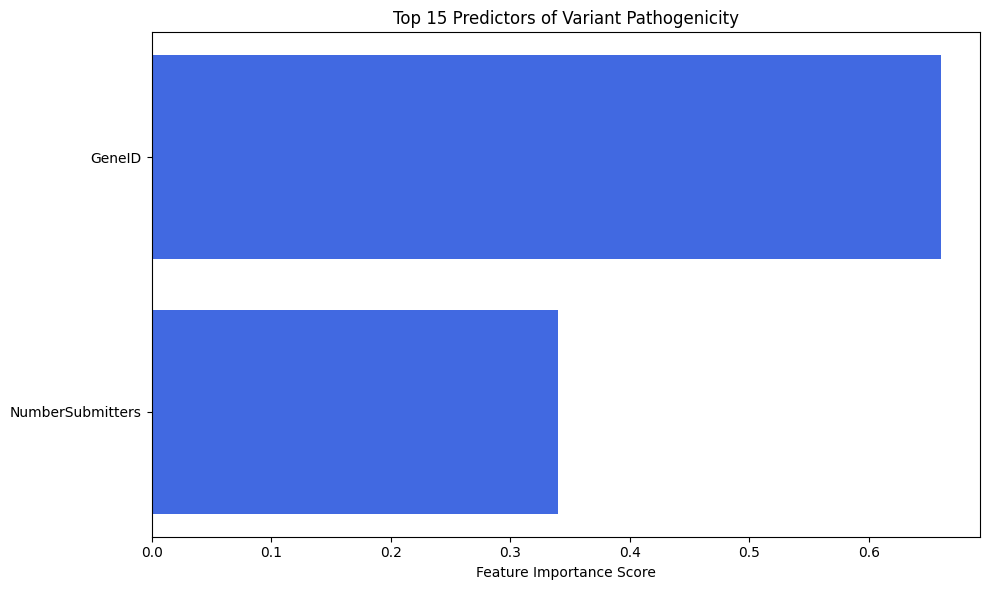

In [35]:
import matplotlib.pyplot as plt

# 6. Extract and organize importance
importances = model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# 7. Plot only the Top 15
top_15 = feat_imp_df.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['Feature'], top_15['Importance'], color='royalblue')
plt.title('Top 15 Predictors of Variant Pathogenicity')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.56      0.52      0.54       182
           1       0.00      0.00      0.00         1
           2       0.34      0.32      0.33       130
           3       0.56      0.71      0.63       295
           4       0.52      0.43      0.47       302

    accuracy                           0.52       910
   macro avg       0.40      0.40      0.39       910
weighted avg       0.52      0.52      0.51       910



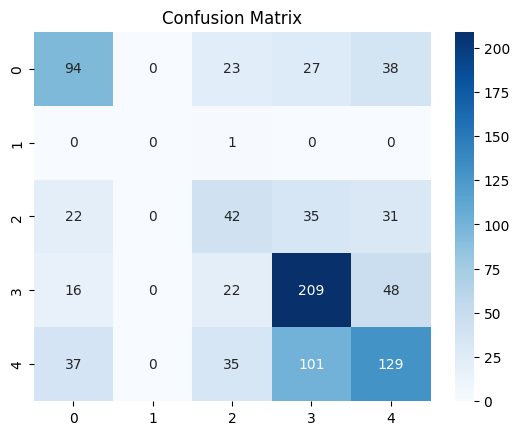

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Make predictions
y_pred = model.predict(X_test)

# Print detailed evaluation
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [17]:
model = RandomForestClassifier(class_weight='balanced', n_estimators=100)

In [18]:
# Check unique labels and their distribution
print(df['ClinicalSignificance'].value_counts())

# If there is a class with very few samples,
# explicitly drop it or combine it with a larger class.

ClinicalSignificance
Likely pathogenic       1652
Pathogenic              1440
Benign                   854
Likely benign            600
Benign/Likely benign       1
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid, cv=3)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [20]:
# 1. Initialize the optimized model
optimized_model = RandomForestClassifier(
    class_weight='balanced',
    max_depth=20,
    min_samples_split=5,
    n_estimators=100,
    random_state=42
)

# 2. Train the model
optimized_model.fit(X_train, y_train)

# 3. Predict and evaluate
from sklearn.metrics import classification_report, confusion_matrix
y_pred = optimized_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.59      0.58       182
           1       0.00      0.00      0.00         1
           2       0.33      0.45      0.38       130
           3       0.59      0.64      0.62       295
           4       0.56      0.42      0.48       302

    accuracy                           0.53       910
   macro avg       0.41      0.42      0.41       910
weighted avg       0.54      0.53      0.53       910



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
# Assuming 'df' is your original dataframe
def group_labels(label):
    if label in [0, 1]: return 0    # Benign
    elif label == 2: return 1       # Uncertain
    else: return 2                  # Pathogenic

df['target_grouped'] = df['target'].apply(group_labels)
y = df['target_grouped']

# Re-run your train_test_split and model training with this new 'y'

In [22]:
from sklearn.model_selection import train_test_split

# Use the new grouped target
y = df['target_grouped']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Initialize with your best parameters
final_model = RandomForestClassifier(
    class_weight='balanced',
    max_depth=20,
    min_samples_split=5,
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, random_state=42)

              precision    recall  f1-score   support

           0       0.56      0.63      0.59       183
           1       0.34      0.46      0.39       130
           2       0.84      0.75      0.79       597

    accuracy                           0.68       910
   macro avg       0.58      0.61      0.59       910
weighted avg       0.71      0.68      0.69       910



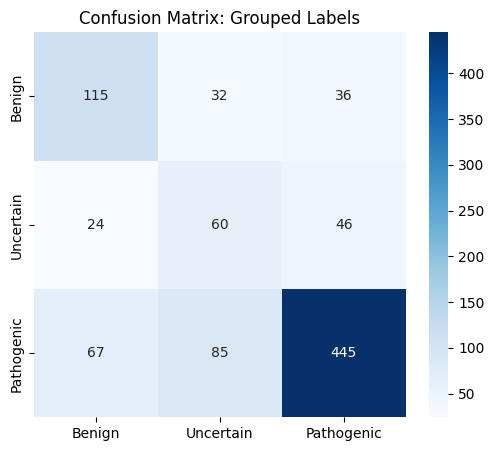

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = final_model.predict(X_test)

# 1. Classification Report
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Uncertain', 'Pathogenic'],
            yticklabels=['Benign', 'Uncertain', 'Pathogenic'])
plt.title('Confusion Matrix: Grouped Labels')
plt.show()

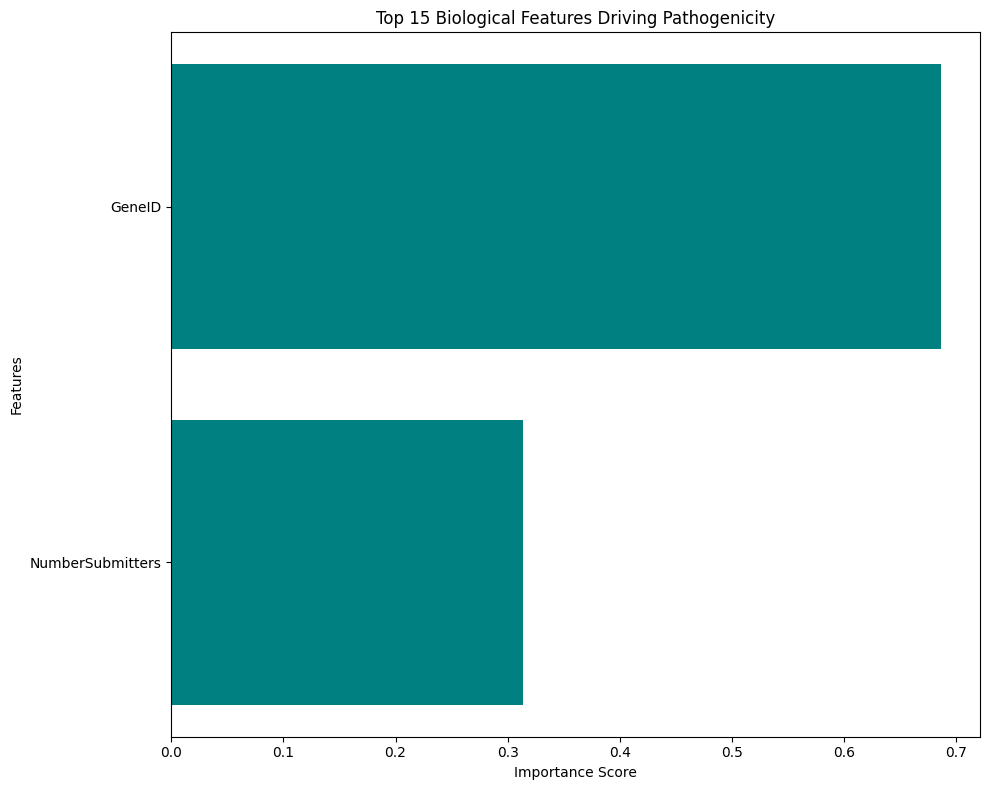

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract feature importances from your trained final_model
importances = final_model.feature_importances_
feature_names = X.columns  # Ensure this matches the columns you trained on

# 2. Create a DataFrame for easy sorting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# 3. Plot Top 15 Features
top_15 = feat_imp_df.tail(15)

plt.figure(figsize=(10, 8))
plt.barh(top_15['Feature'], top_15['Importance'], color='teal')
plt.title('Top 15 Biological Features Driving Pathogenicity')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [26]:
# This list specifies that 'GeneID' is an input feature for your model
features = ['GeneID', 'NumberSubmitters']
X = df[features]

In [27]:
# This shows you the unique Gene IDs present in your dataset
print(df['GeneID'].unique())

[  2157   5172    672   5395   7399   6654   1080    673   6261    675
   4625   6792   9381   4436   2548    999   6442   4653   2200   1785
   3425   2290    659   3172   6121   5897    462   4204   3000   5293
   6927   5053   3690   2628   7450   5605    324     37     24   5781
   2158   2815    861     -1   2645   3949   8216   3561   2956   7157
     94  23474    825   5728   2706   3845   6535   1545   1493   4292
   5894   4647   6323   2593  23405   3674   6443  64072  22800   3575
   8291   5160   5604   6925  51168   6334  23746   2811   3784   7139
   7168   2475   2022   6103   5896  64421   3265   7007    472   5500
   5428  10479   8036     58   4646   7428   6326  22808   8456   6328
 203859   3718   4607   6655   4534   6445  10861   6247   6016    100
   4893  10000  79728   7337   7137   5290   4540   2812   5296   4703
   9132   1690   4508     70   4633]


In [28]:
# A small example of how you can map a few of these IDs
gene_map = {
    672: "BRCA1",
    1080: "CFTR",
    5172: "PINK1",
    # ... and so on
}

# Apply this to your dataframe for the report
df['GeneName'] = df['GeneID'].map(gene_map)

In [29]:
# 1. Install the library (run this once)
!pip install mygene

# 2. Use it to look up your IDs
import mygene
mg = mygene.MyGeneInfo()

# Get your unique IDs from your data
unique_ids = df['GeneID'].unique().tolist()

# Query the database
results = mg.getgenes(unique_ids, fields='symbol')

# Create a dictionary for mapping
gene_map = {res['query']: res.get('symbol', 'Unknown') for res in results}

# Apply to your dataframe
df['GeneName'] = df['GeneID'].map(gene_map)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00


INFO:biothings.client:querying 1-125 ...


In [32]:
# 1. Check if the column exists and has values
print("Does 'GeneName' exist?", 'GeneName' in df.columns)
print("Are there any nulls in 'GeneName'?", df['GeneName'].isnull().sum())

# 2. Let's try a simpler way to get the top genes
top_genes = df['GeneName'].value_counts().head(10)
print(top_genes)

Does 'GeneName' exist? True
Are there any nulls in 'GeneName'? 4547
Series([], Name: count, dtype: int64)


In [38]:
# 1. Print the first few rows to check for 'GeneName'
print("--- Dataframe Head ---")
print(df.head())

# 2. Check if the column exists
if 'GeneName' in df.columns:
    print("\n--- 'GeneName' column exists! ---")
    print("Number of missing values:", df['GeneName'].isnull().sum())

    # 3. Create the data for the plot safely
    data_to_plot = df['GeneName'].value_counts().head(10)
    print("\n--- Data to be plotted ---")
    print(data_to_plot)

    # 4. Only plot if there is data
    if len(data_to_plot) > 0:
        data_to_plot.plot(kind='bar', color='salmon', figsize=(10, 6))
        plt.title('Top 10 Most Frequent Genes')
        plt.xlabel('Gene Symbol')
        plt.ylabel('Count')
        plt.show()
    else:
        print("Data is empty.")
else:
    print("\nERROR: The column 'GeneName' was not found in the dataframe.")

--- Dataframe Head ---
   VariationID  AlleleID GeneSymbol  GeneID    HGNC_ID  \
0      4538570   4650088         F8    2157  HGNC:3546   
1        43528     52697    SLC26A4    5172  HGNC:8818   
2        41806     50245      BRCA1     672  HGNC:1100   
3        41706     50145       PMS2    5395  HGNC:9122   
4        41716     50155       PMS2    5395  HGNC:9122   

                                           Name ClinicalSignificance  \
0        NM_000132.4(F8):c.331G>A (p.Ala111Thr)    Likely pathogenic   
1  NM_000441.2(SLC26A4):c.1963A>G (p.Ile655Val)    Likely pathogenic   
2    NM_007294.4(BRCA1):c.1789G>A (p.Glu597Lys)               Benign   
3     NM_000535.7(PMS2):c.1711C>A (p.Leu571Ile)        Likely benign   
4        NM_000535.7(PMS2):c.59G>A (p.Arg20Gln)               Benign   

  label_2class              ReviewStatus  NumberSubmitters  ... ProteinChange  \
0   Pathogenic  reviewed by expert panel                 1  ...   p.Ala111Thr   
1   Pathogenic  reviewed by exper

In [39]:
# 1. Perform the mapping using the GeneID column
# We create a dictionary map from the results of your previous query
gene_map = {res['query']: res.get('symbol', 'Unknown') for res in results}

# 2. Assign the map to a NEW column named 'GeneName'
df['GeneName'] = df['GeneID'].map(gene_map)

# 3. Verify it was created
print("Does 'GeneName' exist now?", 'GeneName' in df.columns)
print(df[['GeneID', 'GeneName']].head())

Does 'GeneName' exist now? True
   GeneID GeneName
0    2157      NaN
1    5172      NaN
2     672      NaN
3    5395      NaN
4    5395      NaN


In [40]:
# 1. Ensure GeneID is integer type in both
df['GeneID'] = df['GeneID'].astype(int)

# 2. Re-create the map, ensuring the query IDs are integers
gene_map = {int(res['query']): res.get('symbol', 'Unknown') for res in results if 'query' in res}

# 3. Apply the mapping again
df['GeneName'] = df['GeneID'].map(gene_map)

# 4. Check if it worked
print(df[['GeneID', 'GeneName']].head())

   GeneID GeneName
0    2157       F8
1    5172  SLC26A4
2     672    BRCA1
3    5395     PMS2
4    5395     PMS2


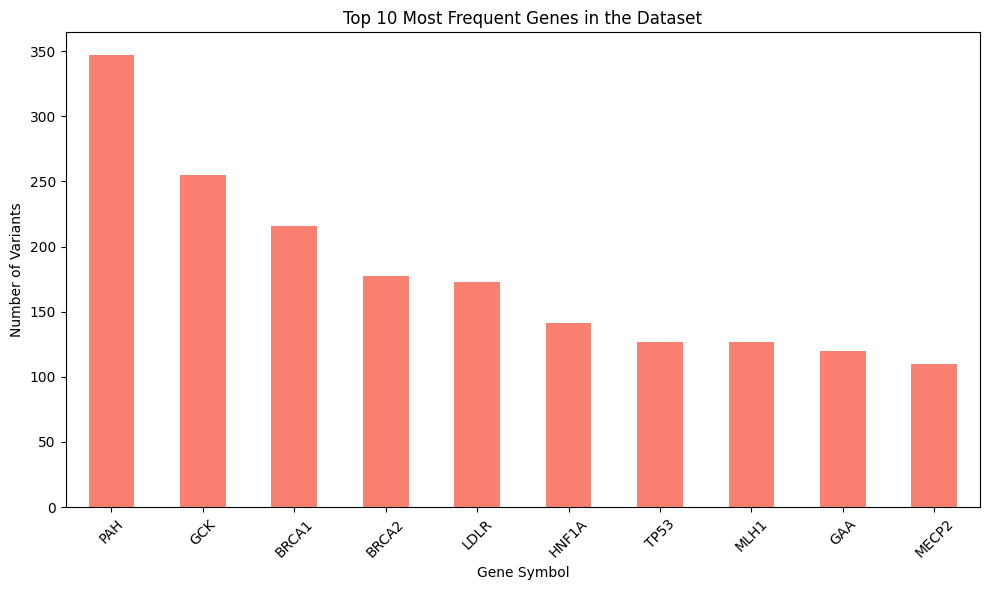

In [41]:
# Create the plot using the successfully mapped 'GeneName' column
top_genes = df['GeneName'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_genes.plot(kind='bar', color='salmon')
plt.title('Top 10 Most Frequent Genes in the Dataset')
plt.xlabel('Gene Symbol')
plt.ylabel('Number of Variants')
plt.xticks(rotation=45) # Rotates labels for better readability
plt.tight_layout()
plt.show()